In [3]:
import zipfile
import os

with zipfile.ZipFile('/content/FruitinAmazon.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/fruits')


os.listdir('/content/fruits')

['FruitinAmazon']

In [19]:
test_dir = '/content/fruits/FruitinAmazon/test'
print(os.listdir(test_dir))

['graviola', 'guarana', 'acai', 'tucuma', 'pupunha', 'cupuacu']


In [20]:
for cls in os.listdir(test_dir):
    count = len(os.listdir(os.path.join(test_dir, cls)))
    print(f"{cls}: {count} images")

graviola: 5 images
guarana: 5 images
acai: 5 images
tucuma: 5 images
pupunha: 5 images
cupuacu: 5 images


In [5]:
import os

train_dir = '/content/fruits/FruitinAmazon/train'
classes = os.listdir(train_dir)
print(classes)

['graviola', 'guarana', 'acai', 'tucuma', 'pupunha', 'cupuacu']


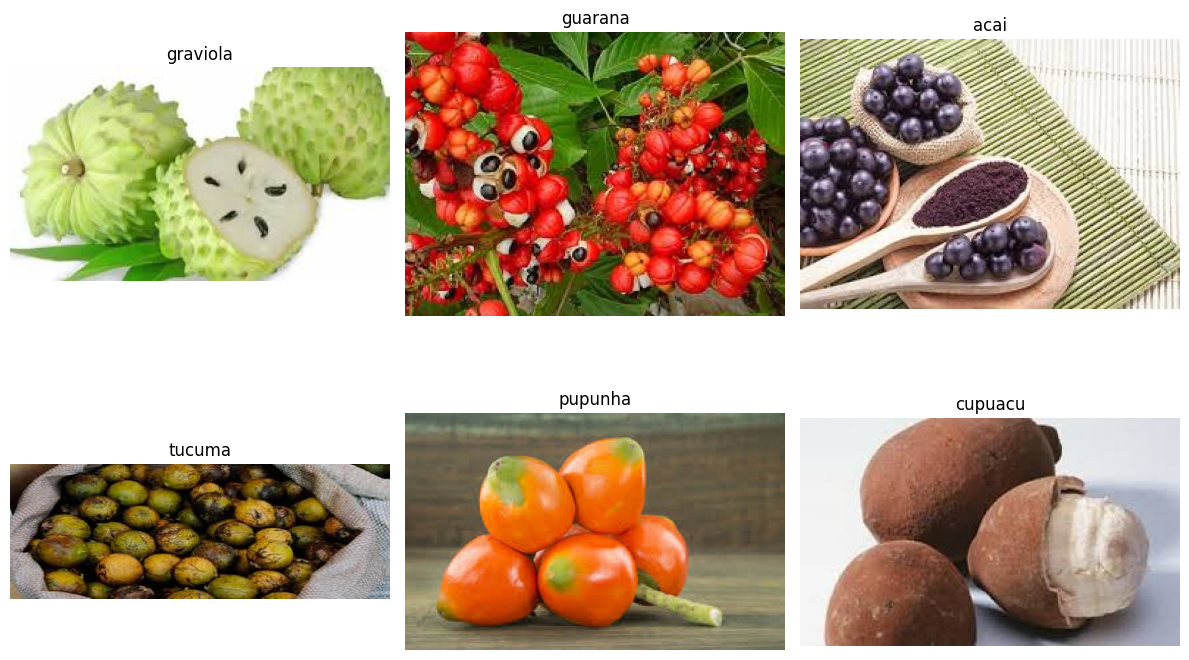

In [6]:
import matplotlib.pyplot as plt
import random
from PIL import Image

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [7]:
from PIL import Image
import os

corrupted = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No corrupted images found.")

No corrupted images found.


In [8]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

In [9]:
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [10]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [11]:
num_classes = len(classes)
print(num_classes)

6


In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(img_height, img_width, 3)),
    tf.keras.layers.MaxPooling2D((2,2), strides=2),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2), strides=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,416,774 (32.11 MB)

 Trainable params: 8,416,774 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss', mode='min')
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.1453 - loss: 3.5728

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 815ms/step - accuracy: 0.1389 - loss: 4.3586 - val_accuracy: 0.8333 - val_loss: 1.0000
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 578ms/step - accuracy: 0.2639 - loss: 1.9132 - val_accuracy: 0.0000e+00 - val_loss: 2.4275
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4306 - loss: 1.6726 - val_accuracy: 0.3889 - val_loss: 1.7192
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 585ms/step - accuracy: 0.6806 - loss: 1.3072 - val_accuracy: 0.6111 - val_loss: 1.2222
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.5787 - loss: 1.1013

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 718ms/step - accuracy: 0.6111 - loss: 1.0725 - val_accuracy: 0.9444 - val_loss: 0.6752
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 574ms/step - accuracy: 0.7639 - loss: 0.7903 - val_accuracy: 0.6667 - val_loss: 1.0755
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.8715 - loss: 0.6168

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 868ms/step - accuracy: 0.8333 - loss: 0.6408 - val_accuracy: 0.8333 - val_loss: 0.5592
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - accuracy: 0.8542 - loss: 0.4527

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 898ms/step - accuracy: 0.8750 - loss: 0.4158 - val_accuracy: 0.8333 - val_loss: 0.4701
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.9554 - loss: 0.2601

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 1.0000 - loss: 0.0359 - val_accuracy: 0.8333 - val_loss: 0.2940
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 1.0000 - loss: 0.0213

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 689ms/step - accuracy: 1.0000 - loss: 0.0235 - val_accuracy: 0.8333 - val_loss: 0.2894
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 1.0000 - loss: 0.0099

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 722ms/step - accuracy: 1.0000 - loss: 0.0092 - val_accuracy: 0.8889 - val_loss: 0.2881
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 1.0000 - loss: 0.0056

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 698ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 0.9444 - val_loss: 0.2373
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 1.0000 - loss: 0.0044

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 710ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 0.8889 - val_loss: 0.2131
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 941ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 0.8889 - val_loss: 0.2262
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 691ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.8889 - val_loss: 0.2403
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 677ms/step - accuracy: 1.0000 - loss: 8.7981e-04 - val_accuracy: 0.8889 - val_loss: 0.2664
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 575ms/step - accuracy: 1.0000 - loss: 7.0780e-04 - val_accuracy: 0.8889 - val_loss: 0.2787
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 601ms/step - accuracy: 1.0000 - loss: 5.8121e-04 - val_accuracy: 0.8889 - val_loss: 0.2757
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 1.0000 - loss: 5.0348e-04 - val_accuracy: 0.8889 - val_loss: 0.2649
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 587ms/step - accuracy: 1.0000 - loss: 4.4904e-04 - val_accuracy

In [21]:
test_dir = '/content/fruits/FruitinAmazon/test'

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [22]:
loss, accuracy = loaded_model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step - accuracy: 0.7667 - loss: 0.7970
Test Loss: 0.7970
Test Accuracy: 0.7667


In [23]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(y_true, y_pred, labels=list(range(len(classes))), target_names=classes))

              precision    recall  f1-score   support

    graviola       1.00      0.80      0.89         5
     guarana       0.56      1.00      0.71         5
        acai       1.00      0.80      0.89         5
      tucuma       0.62      1.00      0.77         5
     pupunha       1.00      0.60      0.75         5
     cupuacu       1.00      0.40      0.57         5

    accuracy                           0.77        30
   macro avg       0.86      0.77      0.76        30
weighted avg       0.86      0.77      0.76        30



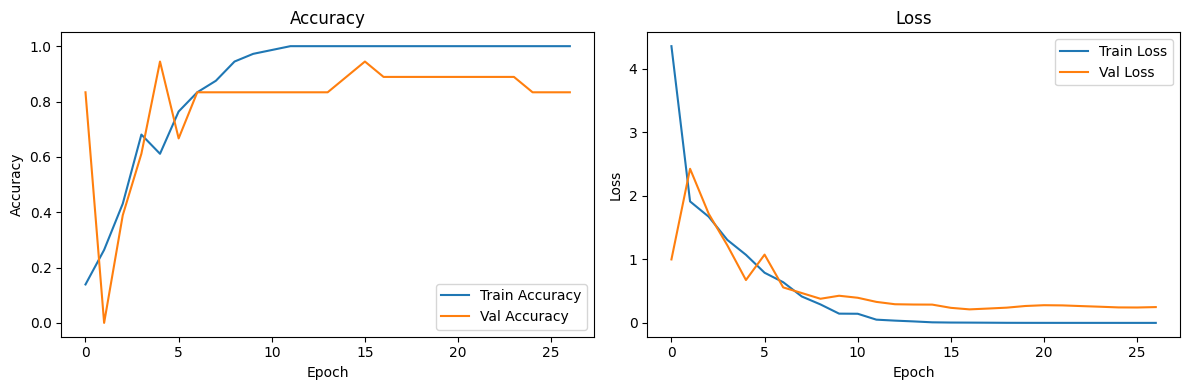

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()